In [22]:
#importando bibliotecas
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
%matplotlib inline

import requests
from io import BytesIO

In [23]:
#carrega a base de bados
df = pd.read_csv('vinhos_dataset_reduced.csv' , index_col=0)

In [24]:
# Certificando que esta usando a df sem duplicadas
df.shape

(5320, 10)

In [25]:
#mostra cabecario e primeiras 5 linhas
df.head()

,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,color,combined_acidity,combined_sulfur_dioxide
citric_acid,,,,,,,,,,
-2.164515,-0.699699,0.523880,1.100996,1.779304,0.177941,-0.969152,5,red,1.594818,-1.753919
-2.164515,-0.544135,1.120736,0.763753,-0.153797,0.979389,-0.631833,5,red,2.565734,-0.786828
-1.892672,-0.610806,0.957957,0.831202,0.220351,0.779027,-0.631833,5,red,2.061356,-1.345931
1.641293,-0.699699,0.496751,1.168444,-0.403229,0.311515,-0.631833,6,red,1.865803,-1.191760
-2.164515,-0.721923,0.496751,1.100996,1.779304,0.177941,-0.969152,5,red,1.426692,-1.599748


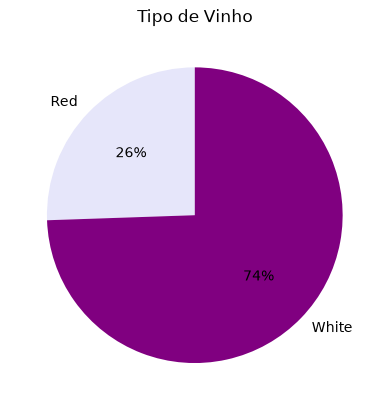

In [26]:
# PLotando em formato pizza a quantidade em % de vinhos red e white
num_red = df[df['color'] == 'red'].shape[0]
num_white = df[df['color'] == 'white'].shape[0]
plt.pie(
    [num_red, num_white],
    labels=['Red', 'White'],
    startangle=90,
    autopct='%1.f%%',
    colors=['lavender', 'purple'])
plt.title('Tipo de Vinho')
plt.show()

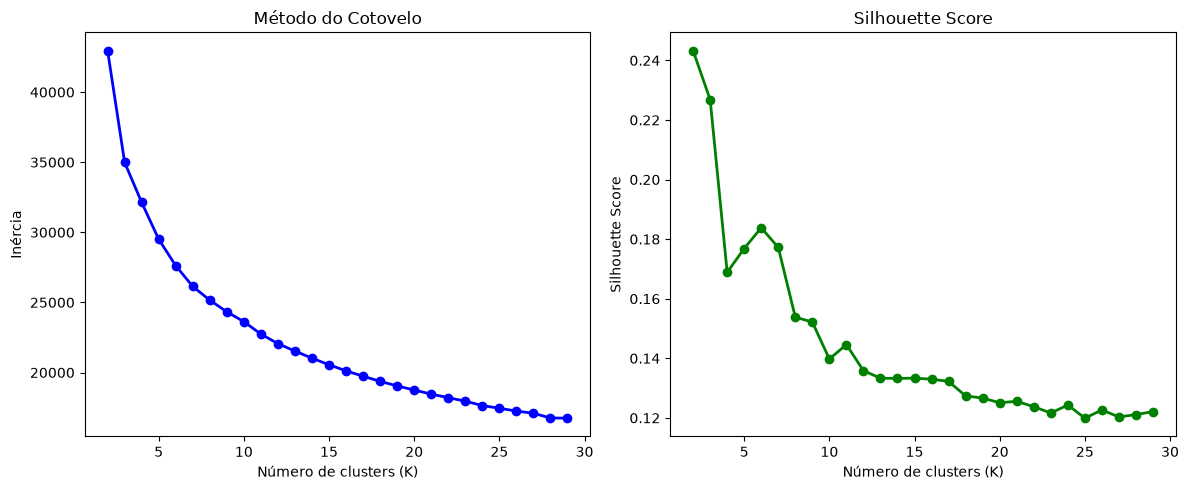

In [27]:
#importando bibliotecas faltantes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Carrega a df novamente (nao entendi porque teve que carregar novamente ?)
df = pd.read_csv(
    "vinhos_dataset_reduced.csv"
)

# Seleciona todos os "features" exceto qualidade e cor
features = [
    'citric_acid', 'residual_sugar', 'chlorides', 'density', 'pH',
       'sulphates', 'alcohol', 'combined_acidity',
       'combined_sulfur_dioxide' , 'quality'
]

X = df[features]

# Faz o scaler dos "features" usando o standardscaler e transforma usando a formula z = X - X_mean / X_std - agora todos os valores estao em escalas parecidas e nao pH entre 1 e 14 e sultatios entre 0 e 1 por examplo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Teste do numero de clusters (nao funcionou com 1 a 30)
ks = range(2, 30)

inercias = []
silhouettes = []

for k in ks:

    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        tol=1e-4,
        random_state=42
    )

    labels = km.fit_predict(X_scaled)

    # Inercia
    inercias.append(km.inertia_)

    # Silhouette
    silhouettes.append(
        silhouette_score(X_scaled, labels)
    )

# Plota os diagnosticos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Elbow
ax1.plot(ks, inercias, 'bo-', linewidth=2)
ax1.set_title('Método do Cotovelo')
ax1.set_xlabel('Número de clusters (K)')
ax1.set_ylabel('Inércia')

# Silhouette
ax2.plot(ks, silhouettes, 'go-', linewidth=2)
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Número de clusters (K)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

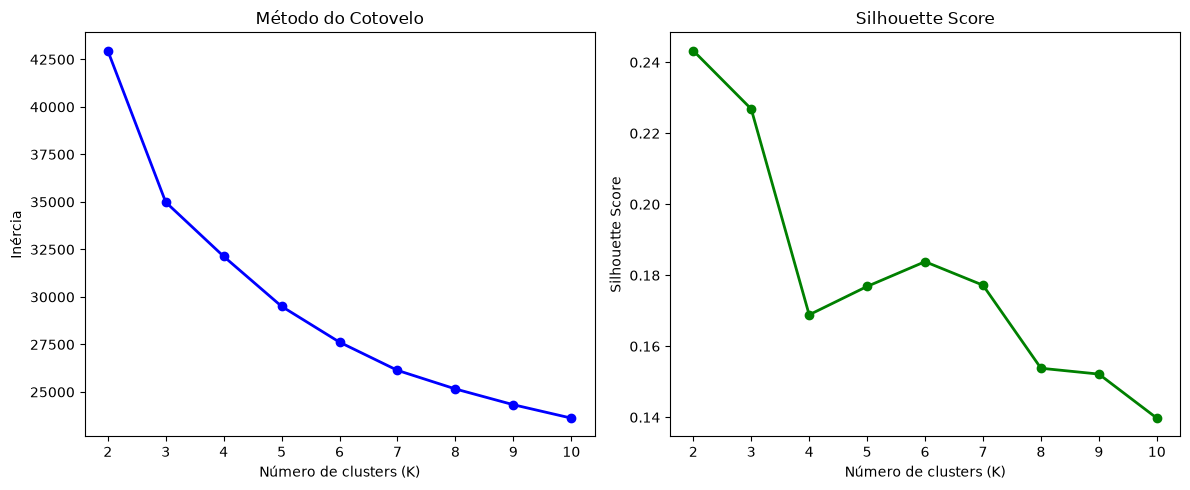

In [28]:
# Teste do numero de clusters (agora somente 10 ks - 2 a 11 por curiosidade)
ks = range(2, 11)

inercias = []
silhouettes = []

for k in ks:

    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        tol=1e-4,
        random_state=42
    )

    labels = km.fit_predict(X_scaled)

    # Inercia
    inercias.append(km.inertia_)

    # Silhouette
    silhouettes.append(
        silhouette_score(X_scaled, labels)
    )

# Plota os diagnosticos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Elbow
ax1.plot(ks, inercias, 'bo-', linewidth=2)
ax1.set_title('Método do Cotovelo')
ax1.set_xlabel('Número de clusters (K)')
ax1.set_ylabel('Inércia')

# Silhouette
ax2.plot(ks, silhouettes, 'go-', linewidth=2)
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Número de clusters (K)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [29]:
# K-Means com 3 clusters (do grafico de Silhoetes (distancia entre pontos mesmo cluster e distancia de outros clusters) no ponto de inflexao ja que o ponto de inflexao de inercia (distancia entre pontos do mesmo cluster) nao e muito nitido)
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

# Ajusta o modelo e atribui cada vinho a um cluster
df['cluster'] = kmeans.fit_predict(X_scaled)

# contagem de vinhos red e whites de cada cluster
cluster_color = pd.crosstab(
    df['cluster'],
    df['color']
)

print(cluster_color)

# contagem de vinhos qualidades de cada cluster
cluster_quality = pd.crosstab(
    df['cluster'],
    df['quality']
)

print(cluster_quality)

color     red  white
cluster             
0        1279     96
1          77   2316
2           3   1549
quality   3   4    5     6    7    8  9
cluster                                
0        12  88  612   514  139   10  0
1         4  60  396  1151  645  132  5
2        14  58  744   658   72    6  0


In [30]:
# Resumo de cada cluster

summary = df.groupby('cluster')[features + ['quality']].agg(
    ['mean', 'std', 'min', 'max']
)

summary

citric_acid                               residual_sugar            \
               mean       std       min       max           mean       std   
cluster                                                                      
0         -0.295270  1.321330 -2.164515  4.631571      -0.555522  0.308783   
1          0.018809  0.744513 -2.164515  9.116989      -0.418090  0.555475   
2          0.232594  0.946861 -2.164515  4.631571       1.136811  1.016497   

                             chlorides            ... combined_sulfur_dioxide  \
              min        max      mean       std  ...                     min   
cluster                                           ...                           
0       -0.944157   2.322686  0.895115  1.402855  ...               -2.420424   
1       -0.988604   2.322686 -0.444618  0.368446  ...               -2.407968   
2       -0.944157  13.501067 -0.107482  0.671115  ...               -2.004680   

                     quality                                                
               max      mean       std min max      mean       std min max  
cluster                                                                     
0         3.014554  5.516364  0.822439   3   8  5.516364  0.822439   3   8  
1         3.785637  6.165483  0.873349   3   9  6.165483  0.873349   3   9  
2        14.344658  5.472938  0.703158   3   8  5.472938  0.703158   3   8  

[3 rows x 44 columns]

Variância explicada - PC1: 26.57%, PC2: 22.82% (Total: 49.40%)


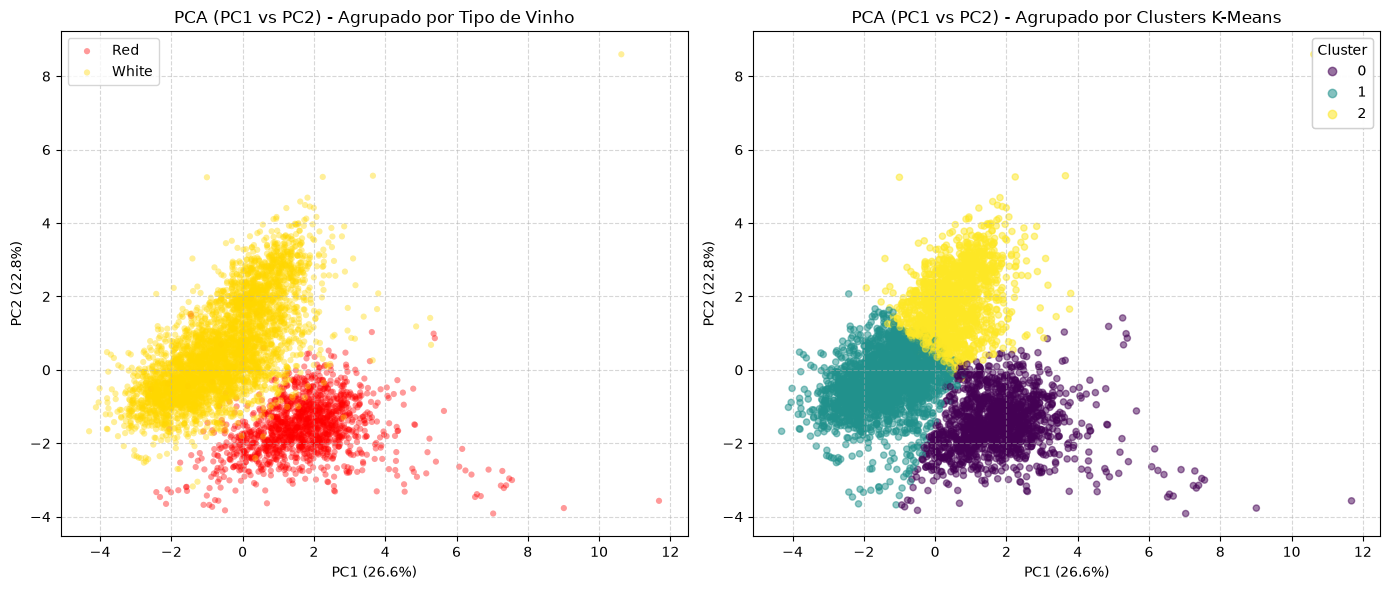

In [31]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Seleção das colunas numéricas (excluindo rótulos/targets)
features = [
    'citric_acid',
    'residual_sugar',
    'chlorides',
    'density',
    'pH',
    'sulphates',
    'alcohol',
    'combined_acidity',
    'combined_sulfur_dioxide',
    'quality'
]

X = df[features]

# Normalização dos dados (requisito do PCA para evitar viés de escala - por excesso de zelo ja que os dados ja foram normalizados)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicação do PCA para 2 componentes principais
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# Criando um DataFrame com PC1 e PC2 juntamente com a cor e os clusters
df_pca = pd.DataFrame(
    data=principal_components, columns=['PC1', 'PC2'], index=df.index
)
df_pca['color'] = df['color']
if 'cluster' in df.columns:
  df_pca['cluster'] = df['cluster']

# Métrica de quanta informação foi mantida
exp_var = pca.explained_variance_ratio_
print(
    f'Variância explicada - PC1: {exp_var[0]*100:.2f}%, PC2:'
    f' {exp_var[1]*100:.2f}% (Total: {sum(exp_var)*100:.2f}%)'
)

# Plotagem do Gráfico 2D

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Mapeamento por Tipo de Vinho (Color)
colors_map = {'red': 'red', 'white': 'gold'}
for wine_type, group in df_pca.groupby('color'):
  ax1.scatter(
      group['PC1'],
      group['PC2'],
      c=colors_map[wine_type],
      label=wine_type.capitalize(),
      alpha=0.4,
      edgecolors='none',
      s=20,
  )

ax1.set_title('PCA (PC1 vs PC2) - Agrupado por Tipo de Vinho')
ax1.set_xlabel(f'PC1 ({exp_var[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({exp_var[1]*100:.1f}%)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Gráfico 2: Mapeamento por Clusters do K-Means (se calculados)
if 'cluster' in df_pca.columns:
  scatter = ax2.scatter(
      df_pca['PC1'],
      df_pca['PC2'],
      c=df_pca['cluster'],
      cmap='viridis',
      alpha=0.5,
      s=20,
  )
  legend2 = ax2.legend(
      *scatter.legend_elements(), title='Cluster', loc='upper right'
  )
  ax2.add_artist(legend2)
  ax2.set_title('PCA (PC1 vs PC2) - Agrupado por Clusters K-Means')
  ax2.set_xlabel(f'PC1 ({exp_var[0]*100:.1f}%)')
  ax2.set_ylabel(f'PC2 ({exp_var[1]*100:.1f}%)')
  ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [32]:
# Obtém os pesos (loadings) das variáveis em PCA1 e PCA2

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PCA1', 'PCA2'],
    index=features
)

print(loadings)

                             PCA1      PCA2
citric_acid              0.021877  0.200545
residual_sugar           0.109679  0.521685
chlorides                0.411598 -0.177807
density                  0.528843  0.201136
pH                       0.006700 -0.288222
sulphates                0.283880 -0.284157
alcohol                 -0.402434 -0.322296
combined_acidity         0.419155 -0.266642
combined_sulfur_dioxide -0.133923  0.512146
quality                 -0.319675 -0.120304


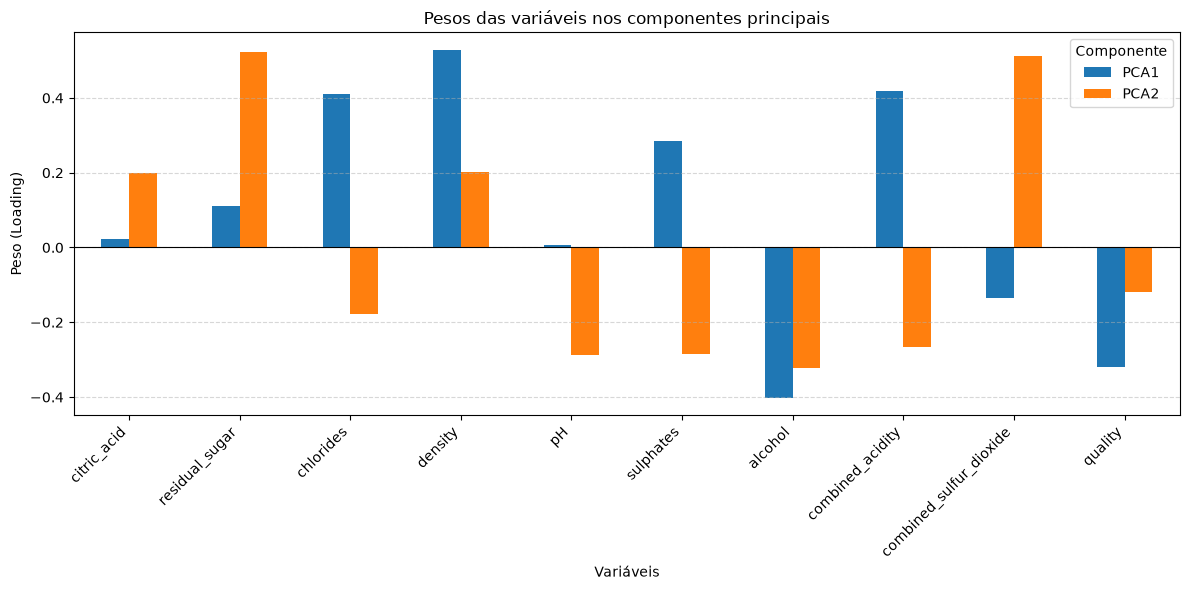

In [33]:
# Gráfico dos pesos das variáveis em PCA1 e PCA2

loadings.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Pesos das variáveis nos componentes principais')
plt.xlabel('Variáveis')
plt.ylabel('Peso (Loading)')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Componente')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

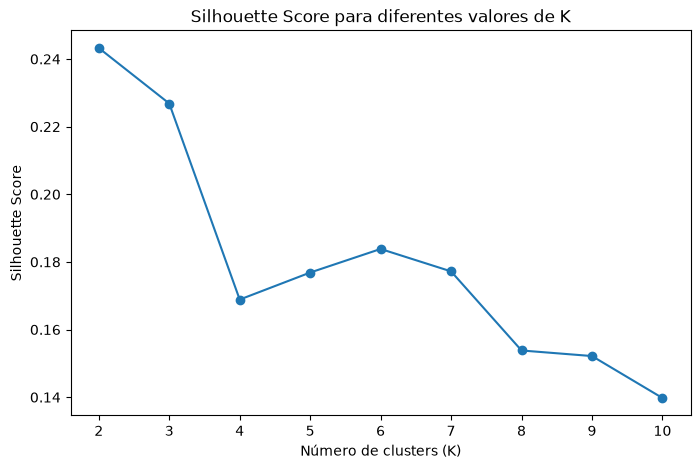

In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score para diferentes valores de K')

plt.show()

Silhouette Score médio: 0.1688682570862828


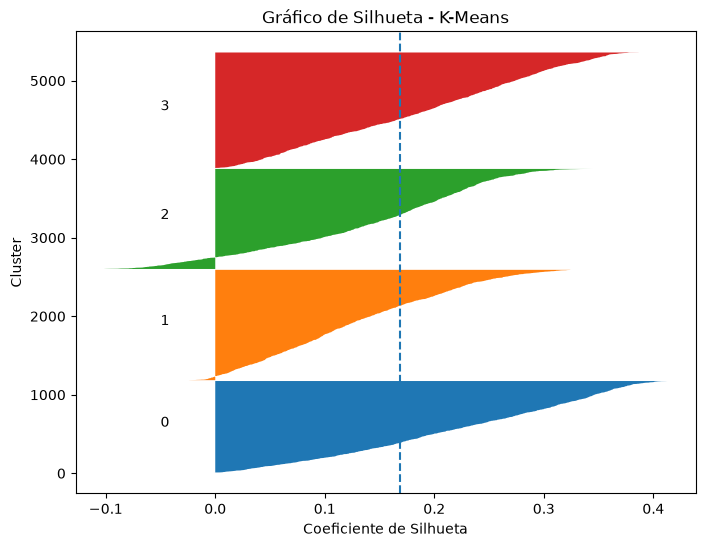

In [35]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Criar o modelo K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Fazer o agrupamento
labels = kmeans.fit_predict(X_scaled)

# Calcular o Silhouette Score médio
silhouette_avg = silhouette_score(X_scaled, labels)

print("Silhouette Score médio:", silhouette_avg)

# Calcular o valor de silhueta de cada observação
sample_silhouette_values = silhouette_samples(X_scaled, labels)

# Criar o gráfico
fig, ax = plt.subplots(figsize=(8, 6))

y_lower = 10

for cluster in range(4):

    # Valores de silhueta do cluster atual
    cluster_values = sample_silhouette_values[labels == cluster]

    # Ordenar os valores
    cluster_values.sort()

    # Tamanho do cluster
    cluster_size = len(cluster_values)

    y_upper = y_lower + cluster_size

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_values
    )

    ax.text(
        -0.05,
        y_lower + 0.5 * cluster_size,
        str(cluster)
    )

    y_lower = y_upper + 10

# Linha mostrando a média
ax.axvline(
    silhouette_avg,
    linestyle="--"
)

ax.set_title("Gráfico de Silhueta - K-Means")
ax.set_xlabel("Coeficiente de Silhueta")
ax.set_ylabel("Cluster")

plt.show()